## Logistic Regression (Логическая регрессия)
#### Исползуется для классификации

Формула линейной части:
$$
z = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n
$$

Потом применяется сигмоидная функция
$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

переводит результат в диапазон
$$
0 \le P \le 1
$$

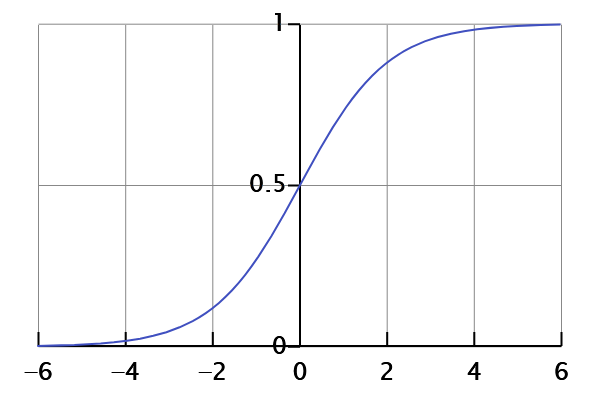


Метрики для логической регрессии:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [8]:
dataset.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [5]:
X = dataset.iloc[:, [2, 3]]
y = dataset.iloc[:, 4]
X, y

(     Age  EstimatedSalary
 0     19            19000
 1     35            20000
 2     26            43000
 3     27            57000
 4     19            76000
 ..   ...              ...
 395   46            41000
 396   51            23000
 397   50            20000
 398   36            33000
 399   49            36000
 
 [400 rows x 2 columns],
 0      0
 1      0
 2      0
 3      0
 4      0
       ..
 395    1
 396    1
 397    1
 398    0
 399    1
 Name: Purchased, Length: 400, dtype: int64)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
X_train

,Age,EstimatedSalary
247,57,122000
110,39,71000
16,47,25000
66,24,19000
153,36,50000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


In [9]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)
X_train

array([[ 1.8925893 ,  1.52189404],
       [ 0.1250379 ,  0.03213212],
       [ 0.9106163 , -1.31157471],
       [-1.34792161, -1.48684082],
       [-0.169554  , -0.58129926],
       [-0.56234321,  2.33980255],
       [ 1.0088136 , -1.19473064],
       [-0.75873781,  1.08372877],
       [ 2.1871812 , -1.04867555],
       [ 0.0268406 , -0.25997806],
       [-0.46414591, -1.1363086 ],
       [ 0.1250379 ,  0.03213212],
       [ 1.6961947 , -0.90262046],
       [ 1.1070109 , -0.90262046],
       [ 0.5178271 ,  1.22978386],
       [-1.05332971, -1.4576298 ],
       [-1.15152701, -1.54526286],
       [-0.0713567 ,  0.67477452],
       [ 0.4196298 , -0.46445519],
       [-0.2677513 , -0.25997806],
       [-0.85693511,  0.14897619],
       [ 0.0268406 ,  0.29503128],
       [ 0.7142217 , -1.28236369],
       [ 1.5979974 ,  1.11293979],
       [ 0.812419  , -1.36999675],
       [-1.44611891, -1.22394166],
       [-0.0713567 ,  0.14897619],
       [ 0.4196298 , -0.14313399],
       [-0.2677513 ,

$$
P(y=1|x) = \sigma(w_0 + w_1x_1 + w_2x_2)
$$

In [10]:
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [11]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[61,  2],
       [12, 25]])



| Метрика   | Формула            | Значение                       |
|-----------|--------------------|--------------------------------|
| Accuracy  | (TP +TN)/total     | (25 + 61)/100 = 0.86           |
| Precision | TP / (TP +FP)      | 25 / (25 + 2) ≈ 0.92           |
| Recall    | TP/ (TP +FN)/total | 25 /(25 + 12) ≈  0.67          |
| F1        | 2PR/(P+R)    | 2*0.92*0.67/(0.92+0.67) ≈ 0.77 |


Accuracy - аккуратность нашей модели = 0.86
Precision - среди предсказанных "купил", сколько действительно купили ≈ 0.92
Recall - среди реально купивших, сколько модель нашла ≈ 0.67
F1 - качество модели ≈ 0.77

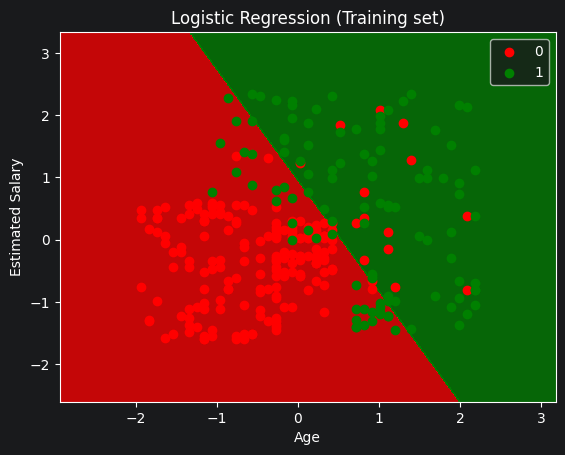

In [12]:
X_Set, y_Set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_Set[:, 0].min() - 1, stop= X_Set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_Set[:, 1].min() - 1, stop= X_Set[:, 1].max() + 1, step=0.01),
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(("red", "green"))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_Set)):
    plt.scatter(
        X_Set[y_Set == j, 0],
        X_Set[y_Set == j, 1],
        label = j,
        color = ListedColormap(("red", "green"))(i),
    )
plt.title("Logistic Regression (Training set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()

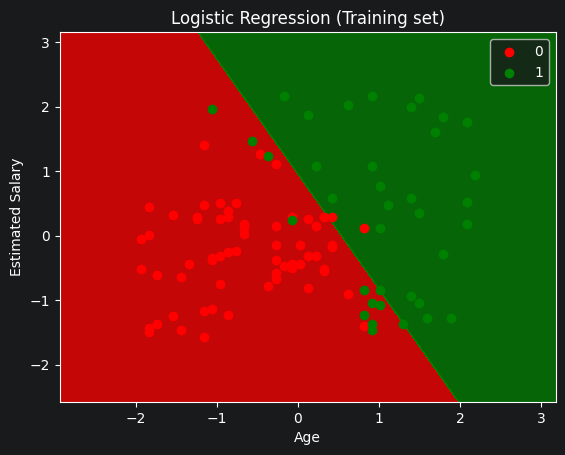

In [13]:
X_Set, y_Set = X_test, y_test

X1, X2 = np.meshgrid(
    np.arange(start=X_Set[:, 0].min() - 1, stop= X_Set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_Set[:, 1].min() - 1, stop= X_Set[:, 1].max() + 1, step=0.01),
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(("red", "green"))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_Set)):
    plt.scatter(
        X_Set[y_Set == j, 0],
        X_Set[y_Set == j, 1],
        label = j,
        color = ListedColormap(("red", "green"))(i),
    )
plt.title("Logistic Regression (Training set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()